In [71]:
# ============================================================
# Notebook 02 - Task 1: Nasdaq Stock Price Prediction
# Tasks:
# 1.1 Multi-feature extension
# 1.2 k-th day forecast
# 1.3 k consecutive days forecast
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [72]:
# ============================================================
# 1. Load AAPL dataset
# ============================================================

df = pd.read_csv("../data/nasdaq/csv/AAPL.csv")

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [73]:
# ============================================================
# 2. Basic data checking
# ============================================================

print(df.shape)
print(df.info())
print(df.isnull().sum())
df.describe()

(10590, 7)
<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            10590 non-null  datetime64[us]
 1   Low             10590 non-null  float64       
 2   Open            10590 non-null  float64       
 3   Volume          10590 non-null  int64         
 4   High            10590 non-null  float64       
 5   Close           10590 non-null  float64       
 6   Adjusted Close  10590 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 579.3 KB
None
Date              0
Low               0
Open              0
Volume            0
High              0
Close             0
Adjusted Close    0
dtype: int64


,Date,Low,Open,Volume,High,Close,Adjusted Close
count,10590,10590.000000,10590.000000,1.059000e+04,10590.000000,10590.000000,10590.000000
mean,2001-12-04 16:56:17.677053,16.141083,16.323966,3.279584e+08,16.509548,16.332145,15.660952
min,1980-12-12 00:00:00,0.049107,0.049665,0.000000e+00,0.049665,0.049107,0.038213
25%,1991-06-04 06:00:00,0.280134,0.286663,1.215564e+08,0.293699,0.286830,0.237230
50%,2001-11-29 12:00:00,0.477500,0.484375,2.151240e+08,0.493304,0.484375,0.401782
75%,2012-06-05 18:00:00,15.800536,16.009286,4.070262e+08,16.179196,15.968750,13.831447
max,2022-12-12 00:00:00,179.119995,182.630005,7.421641e+09,182.940002,182.009995,180.959747
std,NaN,34.495971,34.904787,3.379549e+08,35.327844,34.928490,34.596796


In [74]:
# ============================================================
# 2. Select features and normalize
# ============================================================

features = [
    "Low",
    "Open",
    "Volume",
    "High",
    "Close",
    "Adjusted Close"
]

target_col = "Close"
close_index = features.index(target_col)

data = df[features].copy()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Scaled data shape:", scaled_data.shape)

Scaled data shape: (10590, 6)


In [75]:
# ============================================================
# 4. Normalize data
# ============================================================

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data.shape

(10590, 6)

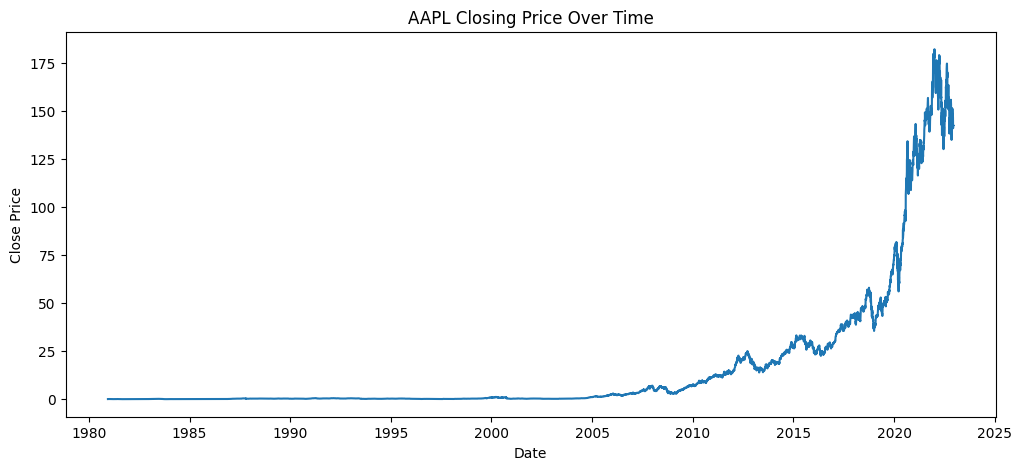

In [76]:
# ============================================================
# 5. Plot original closing price
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [77]:
# ============================================================
# Helper function: train/validation/test split
# ============================================================

def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [78]:
# ============================================================
# Helper function: build CNN model
# ============================================================

def build_cnn_model(window_size, num_features, output_size=1):
    model = Sequential()

    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=(window_size, num_features)
        )
    )

    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))

    model.add(Dense(output_size))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [79]:
# ============================================================
# Helper function: plot training history
# ============================================================

def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.yscale("log")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (log scale)")
    plt.legend()
    plt.show()

In [80]:
# ============================================================
# Helper function: evaluate predictions
# ============================================================

def evaluate_prediction(y_true, y_pred, title):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(title)
    print("RMSE:", rmse)
    print("MAE:", mae)

    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Test Sample")
    plt.ylabel("Normalized Close Price")
    plt.legend()
    plt.show()

    return rmse, mae

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)


In [81]:
# ============================================================
# Task 1.1 - Multi-feature next-day prediction
# ============================================================

window_size = 30

X_1_1 = []
y_1_1 = []

for i in range(window_size, len(scaled_data)):
    X_1_1.append(scaled_data[i - window_size:i])
    y_1_1.append(scaled_data[i, close_index])

X_1_1 = np.array(X_1_1)
y_1_1 = np.array(y_1_1)

print("Task 1.1 X shape:", X_1_1.shape)
print("Task 1.1 y shape:", y_1_1.shape)

Task 1.1 X shape: (10560, 30, 6)
Task 1.1 y shape: (10560,)


In [82]:
# Chronological split

X_train_1_1, X_val_1_1, X_test_1_1, y_train_1_1, y_val_1_1, y_test_1_1 = chronological_split(
    X_1_1,
    y_1_1
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7391, 30, 6) (7391,)
Validation: (1584, 30, 6) (1584,)
Test: (1585, 30, 6) (1585,)


In [83]:
# Build and train model

model_task_1_1 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=1
)

model_task_1_1.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 28, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,689 (229.25 KB)

 Trainable params: 58,689 (229.25 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_1_1 = model_task_1_1.fit(
    X_train_1_1,
    y_train_1_1,
    validation_data=(X_val_1_1, y_val_1_1),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 2.1727e-05 - mae: 0.0025 - val_loss: 3.6924e-04 - val_mae: 0.0158
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.1465e-06 - mae: 0.0016 - val_loss: 5.7721e-05 - val_mae: 0.0056
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8450e-06 - mae: 0.0013 - val_loss: 3.3898e-05 - val_mae: 0.0045
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3110e-06 - mae: 0.0012 - val_loss: 3.0075e-05 - val_mae: 0.0042
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.8263e-06 - mae: 0.0011 - val_loss: 2.6450e-05 - val_mae: 0.0039
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6860e-06 - mae: 0.0011 - val_loss: 3.5714e-05 - val_mae: 0.0047
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.4307e-06 - mae: 0.0011 - val_loss: 9.2522e-05 - val_mae: 0.0083
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.1799e-06 - mae: 0.0010 - val_loss: 2.6916e-05 - 

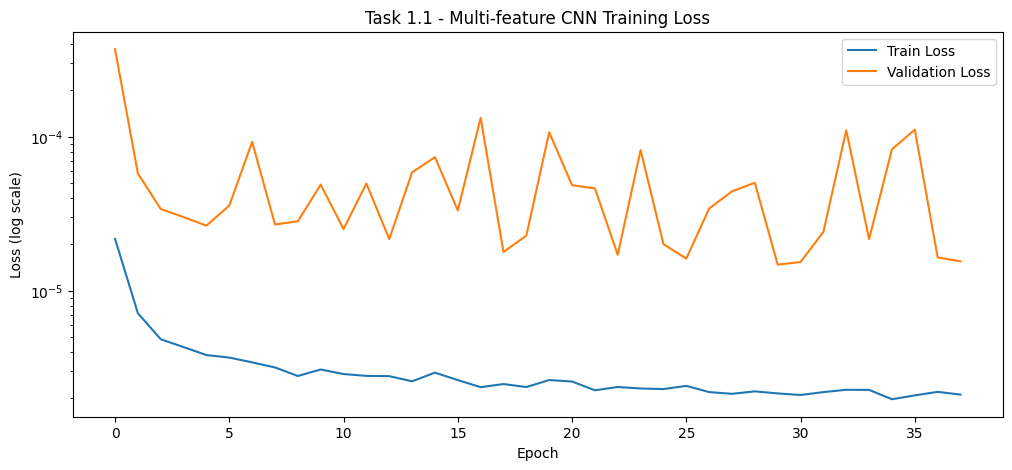

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Task 1.1 - Next-day Close Price Prediction
RMSE: 0.025427830778053627
MAE: 0.017291237746128542


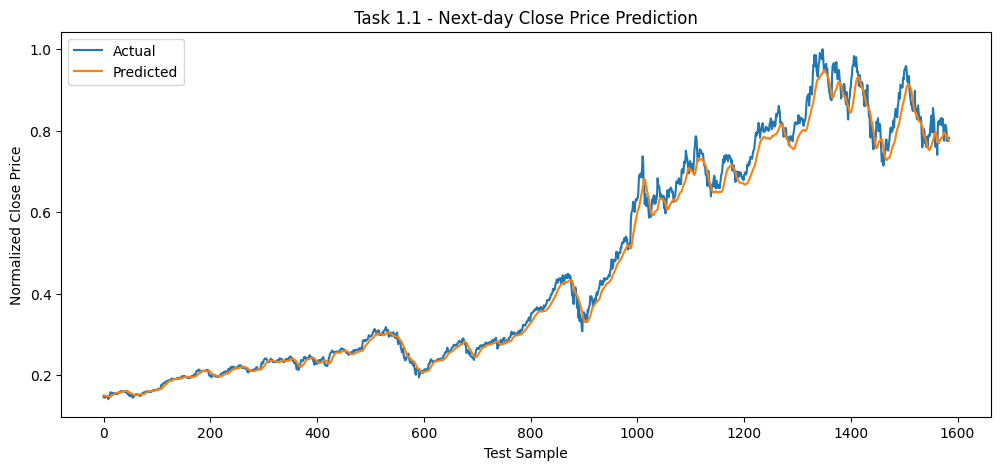

In [85]:
plot_training_history(
    history_1_1,
    "Task 1.1 - Multi-feature CNN Training Loss"
)

pred_1_1 = model_task_1_1.predict(X_test_1_1)

rmse_1_1, mae_1_1 = evaluate_prediction(
    y_test_1_1,
    pred_1_1,
    "Task 1.1 - Next-day Close Price Prediction"
)

In [86]:
cnn_results = pd.DataFrame({
    "Task": [
        "Task 1.1 - Next-day prediction",
        "Task 1.2 - 7th day prediction",
        "Task 1.3 - Next 7 days prediction"
    ],
    "Model": [
        "CNN",
        "CNN",
        "CNN"
    ],
    "RMSE": [
        rmse_1_1,
        rmse_1_2,
        rmse_1_3
    ],
    "MAE": [
        mae_1_1,
        mae_1_2,
        mae_1_3
    ]
})

cnn_results.to_csv("../results/task1_cnn_results.csv", index=False)

cnn_results

,Task,Model,RMSE,MAE
0,Task 1.1 - Next-day prediction,CNN,0.025428,0.017291
1,Task 1.2 - 7th day prediction,CNN,0.160450,0.127591
2,Task 1.3 - Next 7 days prediction,CNN,0.064484,0.044235


In [87]:
# ============================================================
# Task 1.2 - k-th day forecast
# Example: predict the 7th day ahead
# ============================================================

def create_kth_day_dataset(scaled_data, window_size, close_index, k):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(scaled_data[i - window_size:i])
        y.append(scaled_data[i + k - 1, close_index])

    return np.array(X), np.array(y)

In [88]:
k_day = 7

X_1_2, y_1_2 = create_kth_day_dataset(
    scaled_data=scaled_data,
    window_size=window_size,
    close_index=close_index,
    k=k_day
)

print("Task 1.2 X shape:", X_1_2.shape)
print("Task 1.2 y shape:", y_1_2.shape)

Task 1.2 X shape: (10554, 30, 6)
Task 1.2 y shape: (10554,)


In [89]:
X_train_1_2, X_val_1_2, X_test_1_2, y_train_1_2, y_val_1_2, y_test_1_2 = chronological_split(
    X_1_2,
    y_1_2
)

print("Train:", X_train_kth.shape, y_train_kth.shape)
print("Validation:", X_val_kth.shape, y_val_kth.shape)
print("Test:", X_test_kth.shape, y_test_kth.shape)

Train: (7387, 30, 6) (7387,)
Validation: (1583, 30, 6) (1583,)
Test: (1584, 30, 6) (1584,)


In [90]:
model_task_1_2 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=1
)

model_task_1_2.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 28, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,689 (229.25 KB)

 Trainable params: 58,689 (229.25 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
history_1_2 = model_task_1_2.fit(
    X_train_1_2,
    y_train_1_2,
    validation_data=(X_val_1_2, y_val_1_2),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.7174e-05 - mae: 0.0027 - val_loss: 6.5653e-04 - val_mae: 0.0206
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.8853e-06 - mae: 0.0016 - val_loss: 3.6434e-04 - val_mae: 0.0151
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.6756e-06 - mae: 0.0014 - val_loss: 8.7292e-05 - val_mae: 0.0069
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.8464e-06 - mae: 0.0013 - val_loss: 6.9000e-05 - val_mae: 0.0061
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.5949e-06 - mae: 0.0012 - val_loss: 8.6253e-05 - val_mae: 0.0069
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.4282e-06 - mae: 0.0012 - val_loss: 1.2076e-04 - val_mae: 0.0082
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.1835e-06 - mae: 0.0012 - val_loss: 5.3797e-05 - val_mae: 0.0054
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.8655e-06 - mae: 0.0011 - val_loss: 1.8366e-04 - 

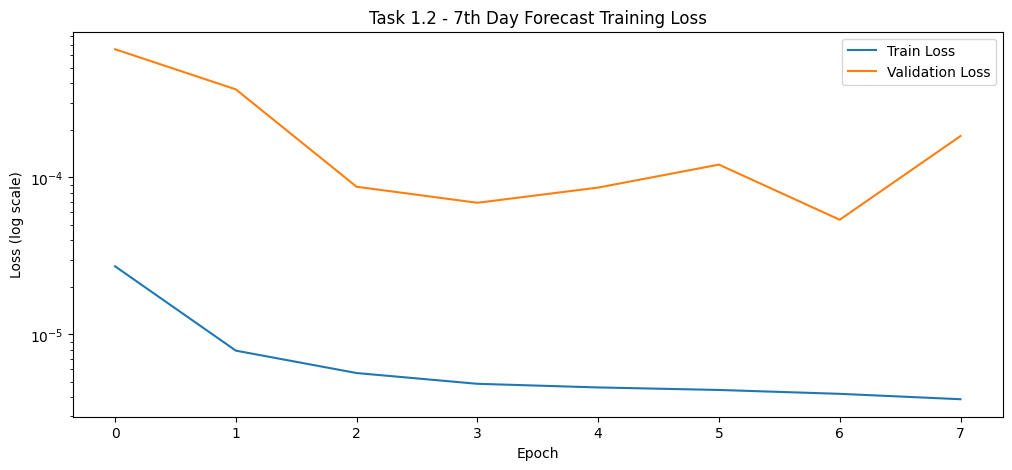

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Task 1.2 - 7th Day Close Price Prediction
RMSE: 0.15954981563566106
MAE: 0.12764540955555245


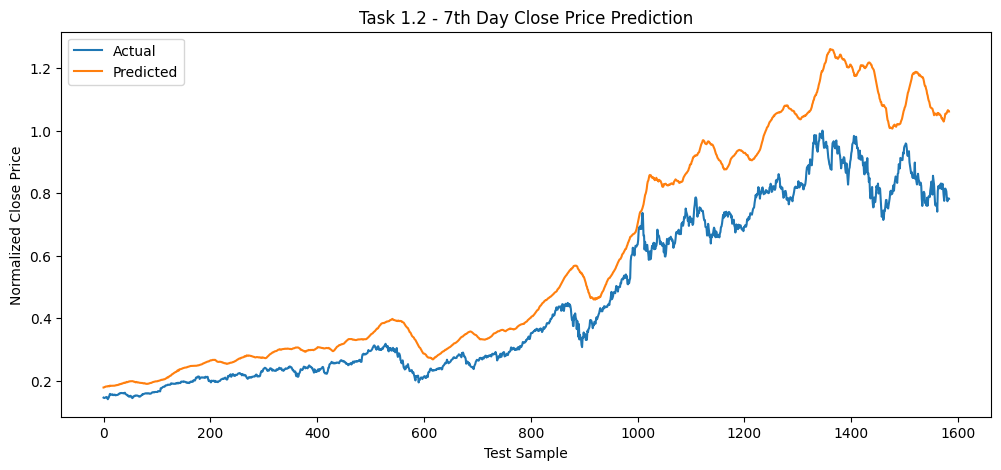

In [92]:
plot_training_history(
    history_1_2,
    f"Task 1.2 - {k_day}th Day Forecast Training Loss"
)

pred_1_2 = model_task_1_2.predict(X_test_1_2)

rmse_1_2, mae_1_2 = evaluate_prediction(
    y_test_1_2,
    pred_1_2,
    f"Task 1.2 - {k_day}th Day Close Price Prediction"
)

In [93]:
# ============================================================
# Task 1.3 - k consecutive days forecast
# Example: predict the next 7 days
# ============================================================

def create_k_days_dataset(scaled_data, window_size, close_index, k):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(scaled_data[i - window_size:i])
        y.append(scaled_data[i:i + k, close_index])

    return np.array(X), np.array(y)

In [94]:
k_days = 7

X_1_3, y_1_3 = create_k_days_dataset(
    scaled_data=scaled_data,
    window_size=window_size,
    close_index=close_index,
    k=k_days
)

print("Task 1.3 X shape:", X_1_3.shape)
print("Task 1.3 y shape:", y_1_3.shape)

Task 1.3 X shape: (10554, 30, 6)
Task 1.3 y shape: (10554, 7)


In [95]:
X_train_1_3, X_val_1_3, X_test_1_3, y_train_1_3, y_val_1_3, y_test_1_3 = chronological_split(
    X_1_3,
    y_1_3
)

print("Train:", X_train_multi.shape, y_train_multi.shape)
print("Validation:", X_val_multi.shape, y_val_multi.shape)
print("Test:", X_test_multi.shape, y_test_multi.shape)

Train: (7387, 30, 6) (7387, 7)
Validation: (1583, 30, 6) (1583, 7)
Test: (1584, 30, 6) (1584, 7)


In [96]:
model_task_1_3 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=k_days
)

model_task_1_3.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 28, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,079 (230.78 KB)

 Trainable params: 59,079 (230.78 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history_1_3 = model_task_1_3.fit(
    X_train_1_3,
    y_train_1_3,
    validation_data=(X_val_1_3, y_val_1_3),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.4251e-05 - mae: 0.0025 - val_loss: 2.5017e-04 - val_mae: 0.0122
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 8.5795e-06 - mae: 0.0016 - val_loss: 1.9856e-04 - val_mae: 0.0104
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.7151e-06 - mae: 0.0014 - val_loss: 4.7388e-04 - val_mae: 0.0168
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.7443e-06 - mae: 0.0013 - val_loss: 1.5122e-04 - val_mae: 0.0087
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5.1997e-06 - mae: 0.0013 - val_loss: 1.0447e-04 - val_mae: 0.0074
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.5260e-06 - mae: 0.0012 - val_loss: 1.3410e-04 - val_mae: 0.0081
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.2090e-06 - mae: 0.0011 - val_loss: 1.3365e-04 - val_mae: 0.0081
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.3009e-06 - mae: 0.0011 - val_loss: 8.3193e-05 - 

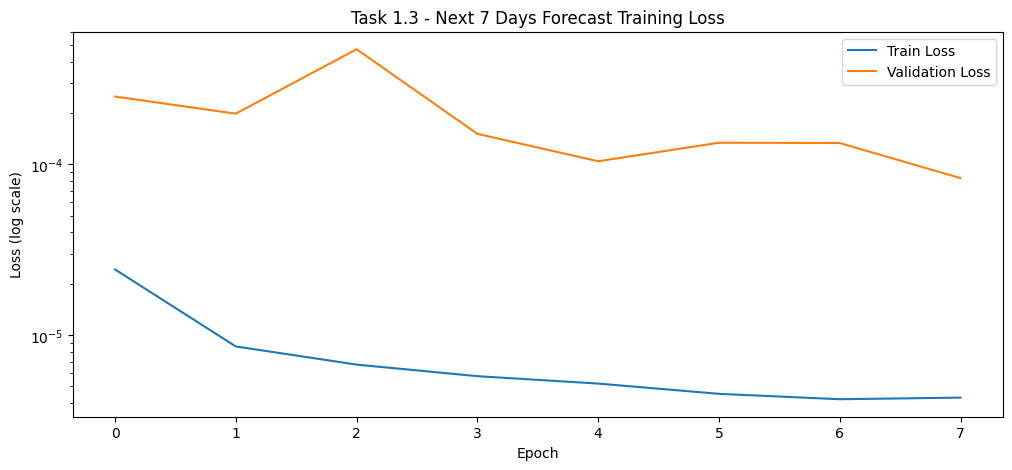

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Task 1.3 - Next 7 Days Forecast
RMSE: 0.09379281617601241
MAE: 0.06862422694604083


In [98]:
plot_training_history(
    history_1_3,
    f"Task 1.3 - Next {k_days} Days Forecast Training Loss"
)

pred_1_3 = model_task_1_3.predict(X_test_1_3)

rmse_1_3 = np.sqrt(
    mean_squared_error(
        y_test_1_3.flatten(),
        pred_1_3.flatten()
    )
)

mae_1_3 = mean_absolute_error(
    y_test_1_3.flatten(),
    pred_1_3.flatten()
)

print(f"Task 1.3 - Next {k_days} Days Forecast")
print("RMSE:", rmse_1_3)
print("MAE:", mae_1_3)

In [99]:
pred_1_3 = model_task_1_3.predict(X_test_multi)

rmse_1_3 = np.sqrt(mean_squared_error(y_test_multi.flatten(), pred_1_3.flatten()))
mae_1_3 = mean_absolute_error(y_test_multi.flatten(), pred_1_3.flatten())

print(f"Task 1.3 - Next {k_days} Days Forecast")
print("RMSE:", rmse_1_3)
print("MAE:", mae_1_3)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Task 1.3 - Next 7 Days Forecast
RMSE: 0.09379281617601241
MAE: 0.06862422694604083


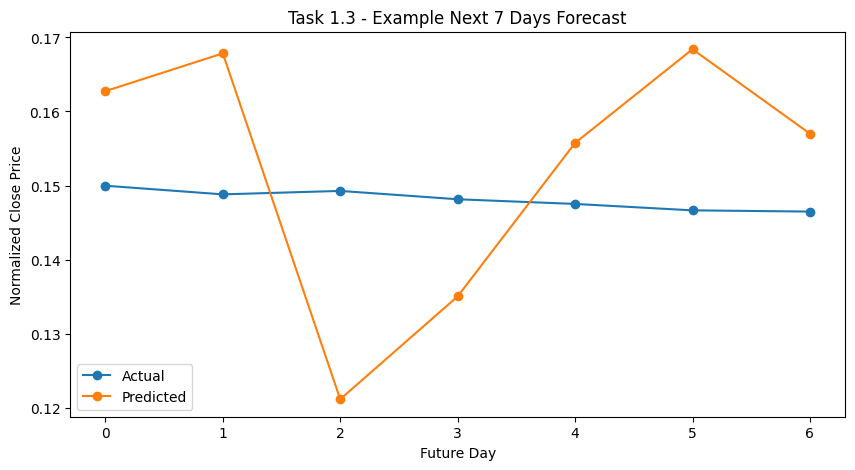

In [100]:
# Plot one example forecast for Task 1.3

sample_index = 0

plt.figure(figsize=(10, 5))
plt.plot(y_test_1_3[sample_index], marker="o", label="Actual")
plt.plot(pred_1_3[sample_index], marker="o", label="Predicted")
plt.title(f"Task 1.3 - Example Next {k_days} Days Forecast")
plt.xlabel("Future Day")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.show()

In [101]:
# ============================================================
# Summary table
# ============================================================

results = pd.DataFrame({
    "Task": [
        "Task 1.1 - Next-day prediction",
        f"Task 1.2 - {k_day}th day prediction",
        f"Task 1.3 - Next {k_days} days prediction"
    ],
    "RMSE": [
        rmse_1_1,
        rmse_1_2,
        rmse_1_3
    ],
    "MAE": [
        mae_1_1,
        mae_1_2,
        mae_1_3
    ]
})

results

,Task,RMSE,MAE
0,Task 1.1 - Next-day prediction,0.025428,0.017291
1,Task 1.2 - 7th day prediction,0.159550,0.127645
2,Task 1.3 - Next 7 days prediction,0.093793,0.068624


In [102]:
results.to_csv("../results/task1_nasdaq_results.csv", index=False)

model_task_1_1.save("../models/task1_1_cnn_next_day.keras")
model_task_1_2.save("../models/task1_2_cnn_kth_day.keras")
model_task_1_3.save("../models/task1_3_cnn_k_days.keras")